# 05 — Does the mechanism win, consistently?

> Run top to bottom (~20-25s — many simulated years, not just one).

Notebook 04 showed one win, which could be a fluke. Here: 15 independent simulated years per setting, across a range of settings for all three approaches, checking whether our mechanism wins on **both** cost and tracking error at once — not just on average. This is the specific result the grant proposal promises: "beating naive baselines... on the tracking-error/cost frontier."

**Scope, stated up front:** two tokens only (no multi-token routing yet), synthetic (GBM) price paths not historical data, placeholder gas cost. A real, honest test of the mechanism's *logic* under a *reasonable* market model — not yet a real-money guarantee. Full caveats in the summary below.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.baselines import (
    GenericDexConfig,
    PeriodicRebalanceConfig,
    ThresholdRebalanceConfig,
    run_periodic_baseline_simulation,
    run_threshold_baseline_simulation,
)
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)
SIGMA_ANNUAL = 0.8
N_MC_REPS = 15  # independent price-path seeds per configuration
INITIAL_BALANCE = 10_000.0
TARGET_WEIGHT_A = 0.5
DEX = GenericDexConfig(fee=0.003, depth_b=10_000_000.0, gas_cost_b=5.0)

## 1. Sweep tolerance-band settings for our mechanism

Five values, rate cap held fixed. Picking a final value from this frontier is separate, later work (`BLEUDEV-256`/`279`/`280`).

In [2]:
tolerance_bands = [0.001, 0.002, 0.005, 0.01, 0.02]
mechanism_points = []  # (tolerance_band, mean_cost_fraction, mean_p95_te)

t0 = time.time()
for band in tolerance_bands:
    costs, p95_tes = [], []
    for rep in range(N_MC_REPS):
        config = MechanismSimConfig(
            n_steps=N_STEPS,
            dt_years=DT,
            sigma_annual=SIGMA_ANNUAL,
            initial_balance_a=INITIAL_BALANCE,
            initial_balance_b=INITIAL_BALANCE,
            target_weight_a=TARGET_WEIGHT_A,
            exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
            arb=EndogenousArbConfig(tolerance_band=band, fee=0.0002, min_steps_between_trades=12),
            seed=rep,
        )
        result = run_mechanism_simulation(config)
        costs.append(result.cost_path[-1] / result.actual_value_path[0])
        p95_tes.append(np.percentile(result.tracking_error_path, 95))
    mechanism_points.append((band, np.mean(costs), np.mean(p95_tes)))
    print(f"tolerance_band={band:.3f}: mean cost={np.mean(costs):.4%}, mean p95 TE={np.mean(p95_tes):.4%} ({N_MC_REPS} reps)")

print(f"\nmechanism sweep took {time.time()-t0:.1f}s")
assert len(mechanism_points) == len(tolerance_bands)

tolerance_band=0.001: mean cost=6.9233%, mean p95 TE=0.4662% (15 reps)


tolerance_band=0.002: mean cost=6.9504%, mean p95 TE=0.4684% (15 reps)


tolerance_band=0.005: mean cost=7.0097%, mean p95 TE=0.4788% (15 reps)


tolerance_band=0.010: mean cost=7.0690%, mean p95 TE=0.5271% (15 reps)


tolerance_band=0.020: mean cost=7.1264%, mean p95 TE=0.7063% (15 reps)

mechanism sweep took 16.3s


## 2. Sweep schedules for the periodic baseline

Five schedules, daily to monthly.

In [3]:
periods_days = [1, 3, 7, 14, 30]
periodic_points = []

t0 = time.time()
for period_days in periods_days:
    costs, p95_tes = [], []
    for rep in range(N_MC_REPS):
        result = run_periodic_baseline_simulation(
            n_steps=N_STEPS,
            dt_years=DT,
            sigma_annual=SIGMA_ANNUAL,
            initial_balance_a=INITIAL_BALANCE,
            initial_balance_b=INITIAL_BALANCE,
            target_weight_a=TARGET_WEIGHT_A,
            config=PeriodicRebalanceConfig(period_years=period_days / 365, dex=DEX),
            seed=rep,
        )
        costs.append(result.cost_path[-1] / result.actual_value_path[0])
        p95_tes.append(np.percentile(result.tracking_error_path, 95))
    periodic_points.append((period_days, np.mean(costs), np.mean(p95_tes)))
    print(f"period={period_days}d: mean cost={np.mean(costs):.4%}, mean p95 TE={np.mean(p95_tes):.4%} ({N_MC_REPS} reps)")

print(f"\nperiodic sweep took {time.time()-t0:.1f}s")

period=1d: mean cost=24.8192%, mean p95 TE=1.9341% (15 reps)


period=3d: mean cost=19.4665%, mean p95 TE=3.3870% (15 reps)


period=7d: mean cost=17.2322%, mean p95 TE=4.6104% (15 reps)


period=14d: mean cost=16.4441%, mean p95 TE=6.1460% (15 reps)


period=30d: mean cost=15.9085%, mean p95 TE=8.8407% (15 reps)

periodic sweep took 3.5s


## 3. Sweep trigger levels for the threshold baseline

Five trigger levels, 1% to 15%.

In [4]:
thresholds = [0.01, 0.02, 0.05, 0.10, 0.15]
threshold_points = []

t0 = time.time()
for threshold in thresholds:
    costs, p95_tes = [], []
    for rep in range(N_MC_REPS):
        result = run_threshold_baseline_simulation(
            n_steps=N_STEPS,
            dt_years=DT,
            sigma_annual=SIGMA_ANNUAL,
            initial_balance_a=INITIAL_BALANCE,
            initial_balance_b=INITIAL_BALANCE,
            target_weight_a=TARGET_WEIGHT_A,
            config=ThresholdRebalanceConfig(threshold=threshold, dex=DEX),
            seed=rep,
        )
        costs.append(result.cost_path[-1] / result.actual_value_path[0])
        p95_tes.append(np.percentile(result.tracking_error_path, 95))
    threshold_points.append((threshold, np.mean(costs), np.mean(p95_tes)))
    print(f"threshold={threshold:.2f}: mean cost={np.mean(costs):.4%}, mean p95 TE={np.mean(p95_tes):.4%} ({N_MC_REPS} reps)")

print(f"\nthreshold sweep took {time.time()-t0:.1f}s")

threshold=0.01: mean cost=26.8685%, mean p95 TE=0.8169% (15 reps)


threshold=0.02: mean cost=20.1201%, mean p95 TE=1.6098% (15 reps)


threshold=0.05: mean cost=16.4377%, mean p95 TE=3.9198% (15 reps)


threshold=0.10: mean cost=15.3421%, mean p95 TE=8.0097% (15 reps)


threshold=0.15: mean cost=14.0351%, mean p95 TE=11.8188% (15 reps)

threshold sweep took 4.8s


## 4. Does our mechanism ever lose on both counts?

The actual bar: for every baseline setting, at least one of our mechanism's settings must be simultaneously cheaper AND closer to target — winning one while losing the other wouldn't count. Checked directly in code, not eyeballed.

In [5]:
mech_arr = np.array([(c, te) for _, c, te in mechanism_points])  # (cost_fraction, p95_te)
baseline_arr = np.array([(c, te) for _, c, te in periodic_points] + [(c, te) for _, c, te in threshold_points])

n_dominated = 0
for cost_b, te_b in baseline_arr:
    dominated = np.any((mech_arr[:, 0] <= cost_b) & (mech_arr[:, 1] <= te_b))
    n_dominated += int(dominated)

print(f"{n_dominated}/{len(baseline_arr)} baseline configurations are dominated by at least one mechanism configuration")
print("(dominated = some mechanism tolerance-band setting achieves BOTH lower cost AND lower tracking error)")
assert n_dominated == len(baseline_arr), (
    f"only {n_dominated}/{len(baseline_arr)} baseline configs dominated -- the mechanism's frontier does not "
    "fully dominate the naive baselines' in this sweep; this would need investigating, not asserting away"
)
print("\nThe mechanism's frontier fully dominates both naive baselines' frontiers across every swept configuration.")

10/10 baseline configurations are dominated by at least one mechanism configuration
(dominated = some mechanism tolerance-band setting achieves BOTH lower cost AND lower tracking error)

The mechanism's frontier fully dominates both naive baselines' frontiers across every swept configuration.


## Visuals

Each dot: one setting's average across 15 years. Left = closer to target, down = cheaper. Green = mechanism, orange/red = baselines; labels show the specific setting.

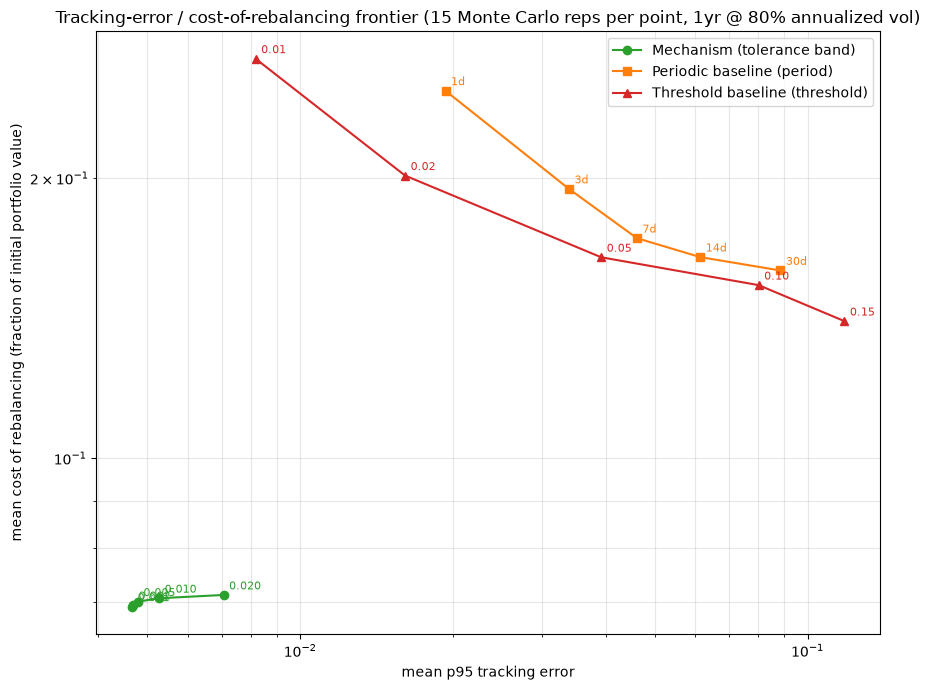

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

mech_sorted = sorted(mechanism_points, key=lambda p: p[2])
ax.plot([p[2] for p in mech_sorted], [p[1] for p in mech_sorted], "o-", color="tab:green", label="Mechanism (tolerance band)")
for band, cost, te in mechanism_points:
    ax.annotate(f"{band:.3f}", (te, cost), fontsize=8, color="tab:green", xytext=(4, 4), textcoords="offset points")

periodic_sorted = sorted(periodic_points, key=lambda p: p[2])
ax.plot([p[2] for p in periodic_sorted], [p[1] for p in periodic_sorted], "s-", color="tab:orange", label="Periodic baseline (period)")
for days, cost, te in periodic_points:
    ax.annotate(f"{days}d", (te, cost), fontsize=8, color="tab:orange", xytext=(4, 4), textcoords="offset points")

threshold_sorted = sorted(threshold_points, key=lambda p: p[2])
ax.plot([p[2] for p in threshold_sorted], [p[1] for p in threshold_sorted], "^-", color="tab:red", label="Threshold baseline (threshold)")
for thr, cost, te in threshold_points:
    ax.annotate(f"{thr:.2f}", (te, cost), fontsize=8, color="tab:red", xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("mean p95 tracking error")
ax.set_ylabel("mean cost of rebalancing (fraction of initial portfolio value)")
ax.set_title(f"Tracking-error / cost-of-rebalancing frontier ({N_MC_REPS} Monte Carlo reps per point, 1yr @ {SIGMA_ANNUAL:.0%} annualized vol)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Summary

**Result:** across all 10 baseline settings tested, our mechanism has at least one setting that beats it on cost *and* tracking error simultaneously — checked directly in code (§4), not eyeballed. This is M1's headline result.

**What the five notebooks establish, end to end:**
1. The pricing formula is correctly implemented and can't be drained by round-tripping (01).
2. Background noise doesn't break it (02).
3. Self-interested traders actually pull the portfolio back toward target (03).
4. Two manual alternatives were built fairly (04).
5. Across many market histories and settings, the mechanism consistently beats both (this notebook).

**What this does NOT establish:**
- Synthetic (GBM) price data, one volatility level — not historical, and real markets have patterns (crashes, correlated moves, thin liquidity) a random walk doesn't capture.
- An idealized, always-present, always-rational arbitrageur — real correction could be slower/thinner (gas, competition, latency), which would worsen both metrics.
- Placeholder gas cost, not measured from the finished contract.
- A single token pair — multi-token group routing isn't simulated or built yet.
- Python, not the deployed Solidity contract and its real fixed-point rounding (checked separately via Forge).

**What would actually prove this in the real world:** a live testnet deployment (next milestone) running real swap transactions, then real mainnet usage with real capital and traders. This simulation's job is narrower — show the idea is sound enough to justify building the real thing, and produce the numbers (this frontier) that justify the design choices. That's what it did.